## Load .h5 file and color assignment

In [1]:
import sys
import os
sys.path.append(os.path.expanduser("../"))

import decode
import decode.utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import matplotlib.patches as patches


print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

/data1/shah/miniconda3/envs/decode_uipsf/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


DECODE version: vINVALID-recent-1.0.0dev0


In [2]:
device = 'cuda:0'  # or 'cpu', or you change cuda device index
threads = 4  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 0  # number of workers for data loading. Used a default of 0 for safety. Multiprocessing on windows is sometimes not stable

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if not torch.cuda.is_available():
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

## Load Experimental Results
Specify Post-Processing as by the parameter file you trained the model with

In [3]:
em_path = '../results/Fig2b-240802_NC_ER_MT_TritonX100_2percent_2_MMStack_Default.ome_decode_plex_fit_model_Fig2b-dual_color-reticulum_microtubes.h5'
# em_path = '/home/shah/projects/DECODE_PLEX/data/dual_color/240802_NC_ER_MT_TritonX100_08percent_1_MMStack_Default.ome_decode_plex_fit_model_2025-05-15_16-uiPSF-uiTrafo.h5'
em = decode.EmitterSet.load(em_path)

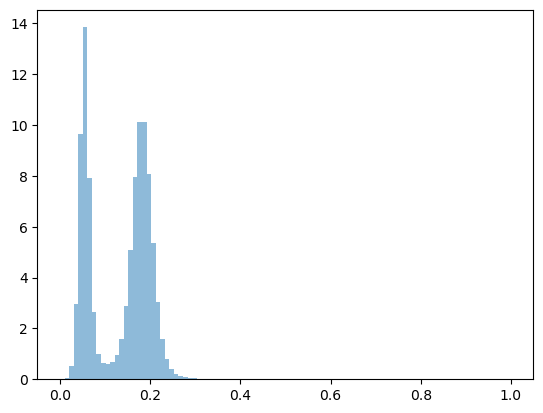

In [4]:
bins = torch.linspace(0, 1, 100)
em_p = em.clone()
em_p = em_p[em_p.prob > 0.6]
em_p = em_p[em_p.xyz_sig_lat_nm < 20]

phot_norm = em_p.phot[:, 0] / (em_p.phot.sum(1))

phot_norm = phot_norm.numpy()

_ = plt.hist(phot_norm, bins=bins, alpha=0.5, label="p0/(p0+p1)", density=True)
# plt.hist(ratio)


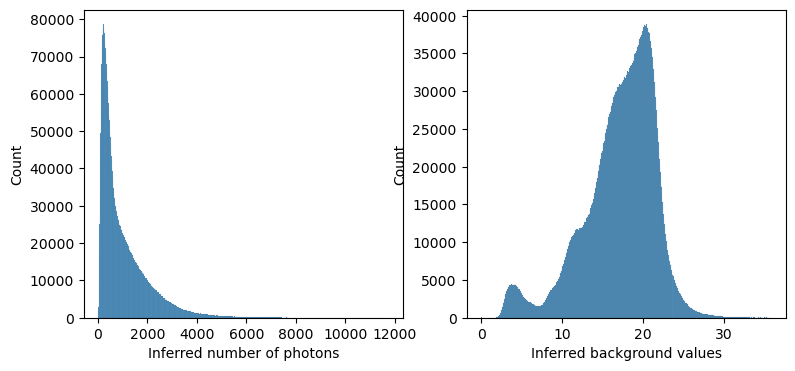

In [5]:
plt.figure(figsize=(14,4))

# bins = torch.linspace(0, em.phot[0].max(), 100)
plt.subplot(131)
sns.histplot(em_p.phot[:,0].numpy())
plt.xlabel('Inferred number of photons')
# plt.xlim([50000,60000])
# plt.xlim(0)

plt.subplot(132)
sns.histplot(em_p.bg[:, 0].numpy())
plt.xlabel('Inferred background values')

plt.show()

### Fit Gaussion Mixture Model
using Gaussion mixture model to determine the ration between different channels.


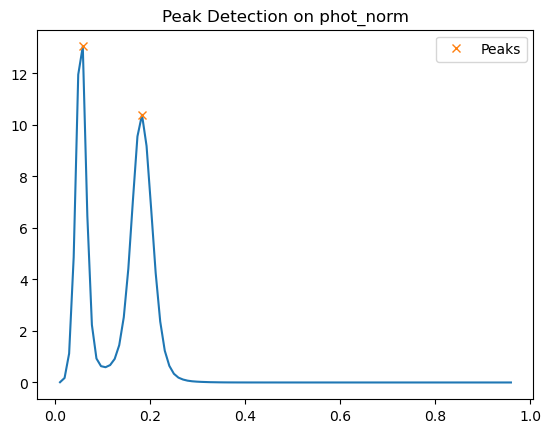

Peak positions: [0.05814644 0.18274482]


In [6]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import numpy as np

hist, bin_edges = np.histogram(phot_norm, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

peaks, _ = find_peaks(hist, distance=5, prominence=0.02)

ratios = bin_centers[peaks]

plt.plot(bin_centers, hist)
plt.plot(bin_centers[peaks], hist[peaks], "x", label="Peaks")
plt.title("Peak Detection on phot_norm")
plt.legend()
plt.show()

print("Peak positions:", ratios)

## Color assignment

In [7]:
# choric
# ratios = [0.79873455, 0.9360013]
choric_lin = torch.as_tensor(ratios)[:2]
choric_mat = decode.simulation.trafo.photon.utils.dual_from_ratio(choric_lin, 1)

print(choric_mat)


em_out = em_p.clone()
em_out.assign_prob_code_(choric_mat.T)

ix_val = torch.ones(len(em_out), dtype=torch.bool)

ix_clear = (em_out.prob_code > 0.9).max(1)[0]
em_out.code = torch.ones(len(em_out), dtype=torch.long) * -1
em_out.code[ix_clear] = em_out.prob_code[ix_clear].argmax(1)

tensor([[0.0581, 0.9419],
        [0.1827, 0.8173]])


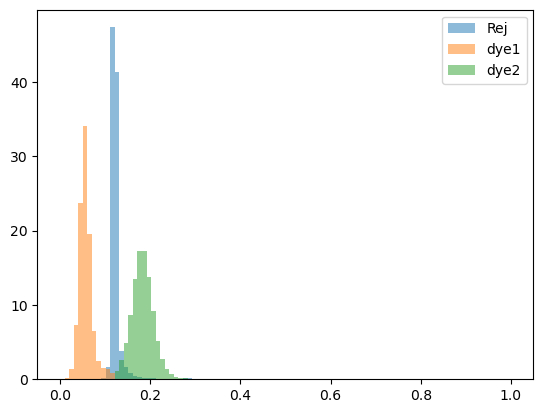

In [8]:
bins = torch.linspace(0, 1, 100)

code ={"Rej":-1, "dye1": 0, "dye2": 1}

for k, v in code.items():
    ep = em_out.icode[v]
    ep = ep[ep.prob > 0.6]
    phot_norm = ep.phot[:, 0] / (ep.phot.sum(1))
    _ = plt.hist(phot_norm.numpy(), bins=bins, alpha=0.5, label=k, density=True)

plt.legend()

99.30535198708164% emitters are divided


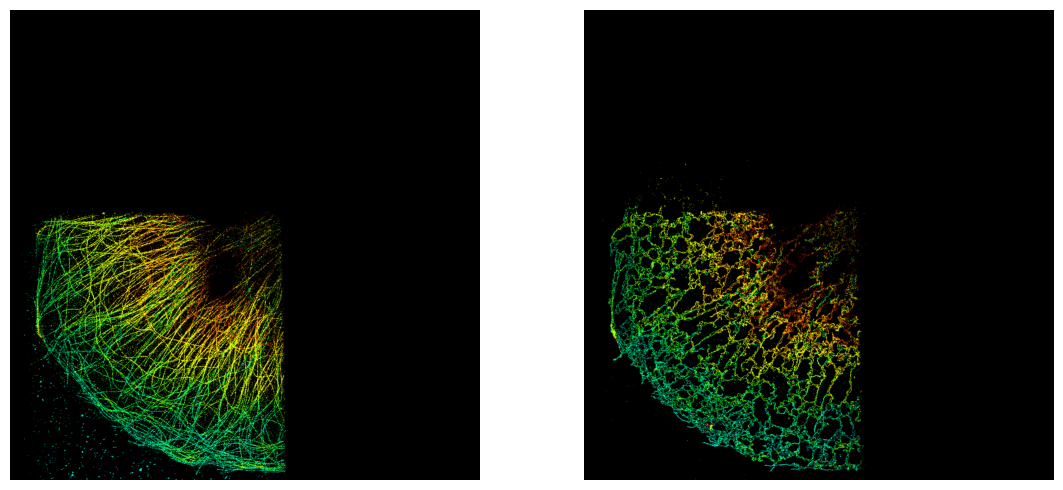

In [9]:
# em_out = em.clone()
em_p = em_out.clone()
# em_p = em_p[em_p.prob > 0.6]
# em_p = em_p[em_p.xyz_sig_lat_nm < 40]

em_ch0 = em_p[em_p.code==0]
em_ch1 = em_p[em_p.code==1]

# rendering
import matplotlib as mpl
px_size = em_out.px_size

xextent = (0, 400 * px_size[0])
yextent = (0, 400 * px_size[1])
zextent = (-500., 500.)

renderer = decode.renderer.renderer.Renderer2D(
    xextent=xextent,
    yextent=xextent,
    colextent=zextent,
    px_size=10.,
    sigma_blur=10.,
    rel_clip=0.05,
    contrast=4.,
    cmap="turbo",
)

img0 = renderer.forward(em_ch0, em_ch0.xyz[:, 2])
img1 = renderer.forward(em_ch1, em_ch1.xyz[:, 2])

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))

im0 = ax[0].imshow(img0.permute(1, 0, 2))
ax[0].axis('off')

im1 = ax[1].imshow(img1.permute(1, 0, 2))
ax[1].axis('off')

# Add the colorbar to the inset_axes
plt.tight_layout()

accept_rate = (len(em_ch0) + len(em_ch1)) / len(em_out)
print(f"{accept_rate * 100}% emitters are divided")


## Save to emitters

In [11]:
path_out = Path(em_path)
path_out = "../results/color_assignment/" + f"{path_out.stem}_color_assignment.h5"
em_out.save(path_out)
print(f"Saved to {path_out}")

Saved to ../results/color_assignment/Fig2b-240802_NC_ER_MT_TritonX100_2percent_2_MMStack_Default.ome_decode_plex_fit_model_Fig2b-dual_color-reticulum_microtubes_color_assignment.h5
